# 02. EDA — Playground Series S6E7 (Predicting Student Health Risk)

타겟: `health_condition` (at-risk / unhealthy / fit), 평가지표: Balanced Accuracy

원본 `train.csv`(결측/원본 카테고리 라벨 보존)를 사용해서 다음을 확인합니다.
1. 타겟 분포
2. 수치형 피처 분포 및 타겟별 차이
3. 범주형 피처와 타겟의 관계
4. 수치형 피처 간 상관관계
5. 결측 여부와 타겟의 관계 (전처리에서 만든 `_isnull` 플래그가 실제로 신호가 있는지 검증)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

DATA_DIR = Path("../playground-series-s6e7")
train = pd.read_csv(DATA_DIR / "train.csv")

TARGET = "health_condition"
TARGET_ORDER = ["fit", "at-risk", "unhealthy"]

NUMERIC_COLS = [
    "sleep_duration", "heart_rate", "bmi", "calorie_expenditure",
    "step_count", "exercise_duration", "water_intake",
]
CATEGORICAL_COLS = [
    "diet_type", "stress_level", "sleep_quality",
    "physical_activity_level", "smoking_alcohol", "gender",
]

print(train.shape)
train.head()

(690088, 15)


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


## 1. 타겟 분포

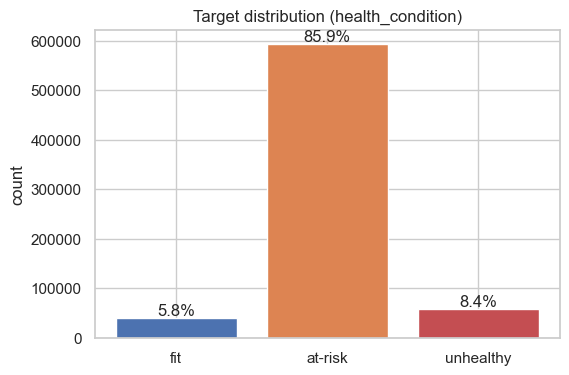

health_condition
fit           39803
at-risk      592561
unhealthy     57724
Name: count, dtype: int64
health_condition
fit           5.77
at-risk      85.87
unhealthy     8.36
Name: count, dtype: float64


In [2]:
counts = train[TARGET].value_counts().reindex(TARGET_ORDER)
pct = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=["#4C72B0", "#DD8452", "#C44E52"])
for bar, p in zip(bars, pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{p:.1f}%",
            ha="center", va="bottom")
ax.set_title("Target distribution (health_condition)")
ax.set_ylabel("count")
plt.show()

print(counts)
print(pct.round(2))

## 2. 수치형 피처 분포 (타겟별)

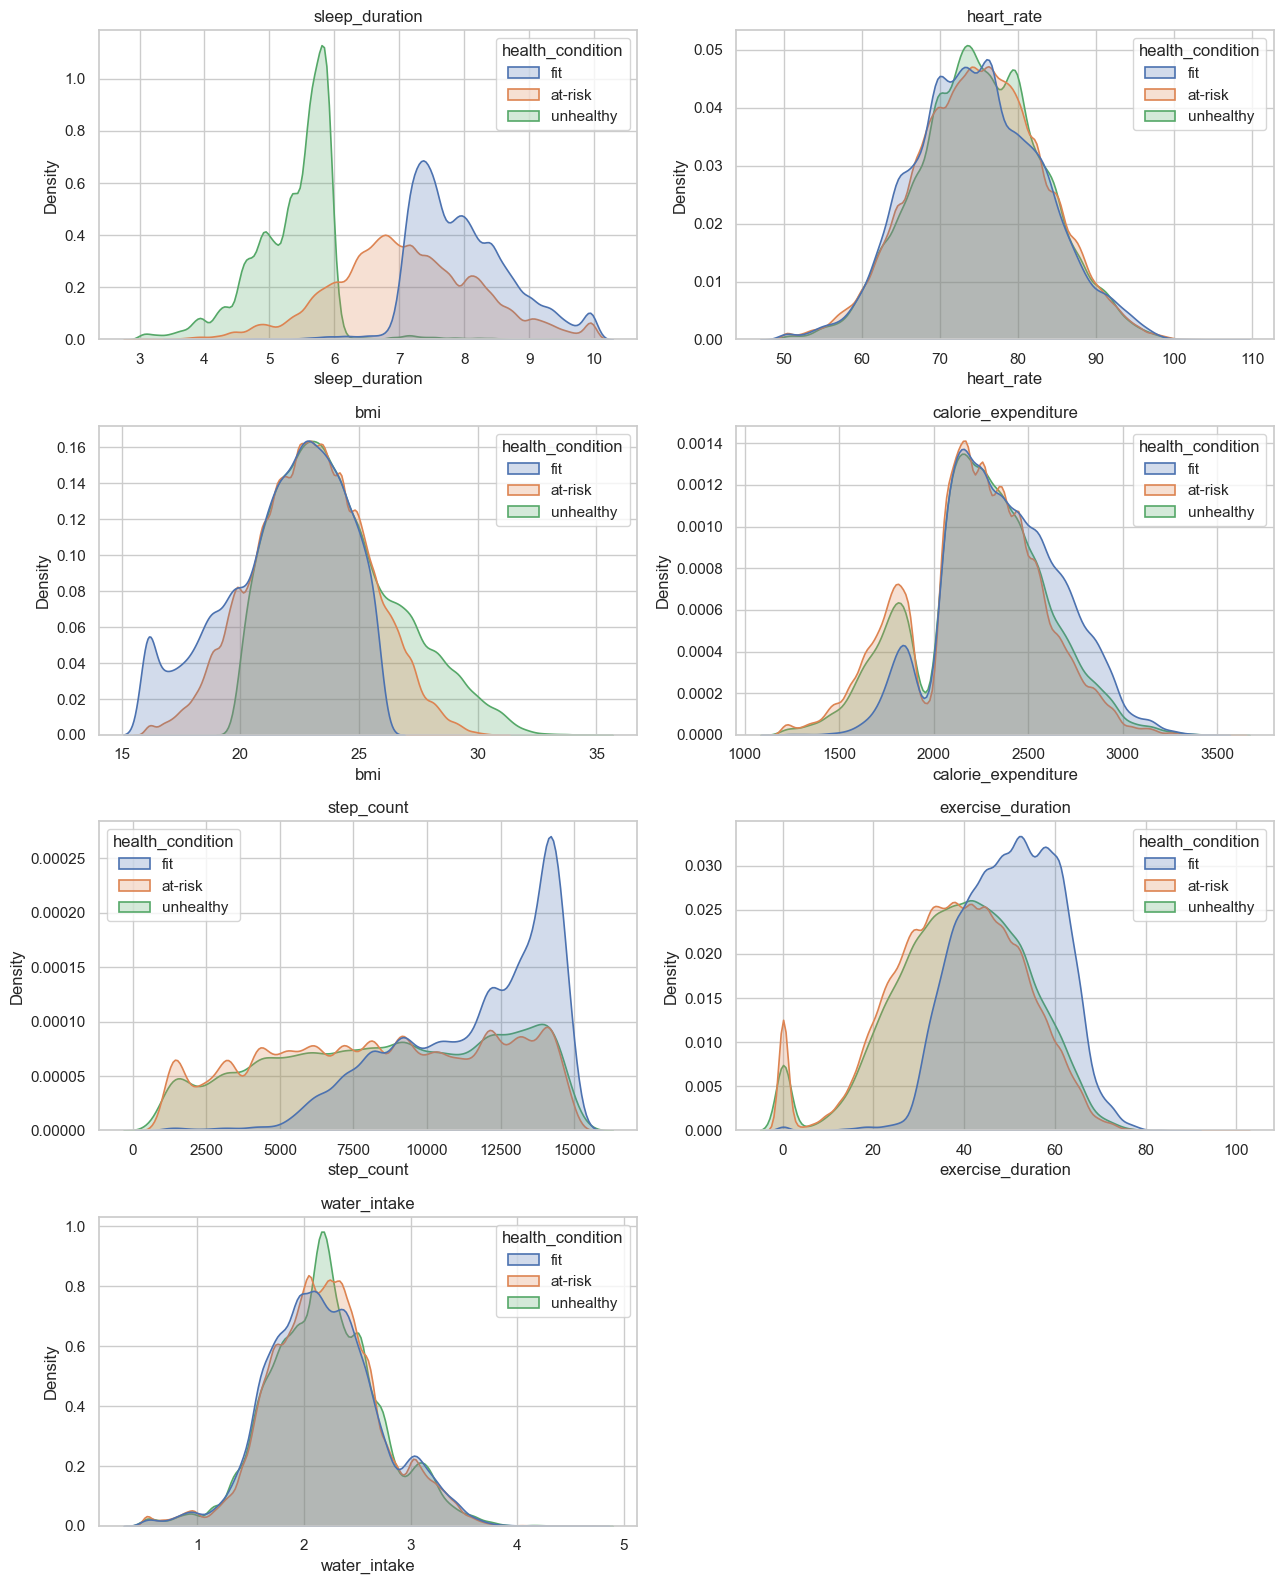

In [3]:
fig, axes = plt.subplots(4, 2, figsize=(13, 16))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    sns.kdeplot(
        data=train, x=col, hue=TARGET, hue_order=TARGET_ORDER,
        common_norm=False, ax=axes[i], fill=True, alpha=0.25, linewidth=1.2,
    )
    axes[i].set_title(col)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

In [4]:
train.groupby(TARGET)[NUMERIC_COLS].agg(["mean", "median", "std"]).T

health_condition                at-risk           fit    unhealthy
sleep_duration      mean       7.086467      7.954311     5.366118
                    median     7.030000      7.840000     5.530000
                    std        1.143340      0.777578     0.670365
heart_rate          mean      75.100534     74.803742    75.256903
                    median    75.100000     74.500000    75.100000
                    std        8.192666      8.222343     7.954250
bmi                 mean      22.949591     21.828544    24.122660
                    median    22.960000     22.250000    23.700000
                    std        2.422431      2.531088     2.594285
calorie_expenditure mean    2214.943466   2363.992052  2245.420223
                    median  2235.000000   2345.000000  2255.000000
                    std      347.625289    312.395560   348.343560
step_count          mean    8406.705910  11651.307024  8670.234090
                    median  8483.000000  12342.500000  8941.500000
                    std     3917.807940   2655.613290  3918.243166
exercise_duration   mean      37.964960     50.042381    39.044280
                    median    38.600000     50.500000    39.700000
                    std       14.677118     10.541754    14.693088
water_intake        mean       2.189130      2.179176     2.188961
                    median     2.180000      2.140000     2.180000
                    std        0.517423      0.530531     0.520977

## 3. 범주형 피처와 타겟의 관계

각 카테고리 내에서 타겟 클래스 비율(row-normalized)을 봅니다. 전체 평균(at-risk 85.9% / unhealthy 8.4% / fit 5.8%)과 비교해서 편차가 크면 해당 카테고리가 타겟과 관련이 있다는 뜻입니다.

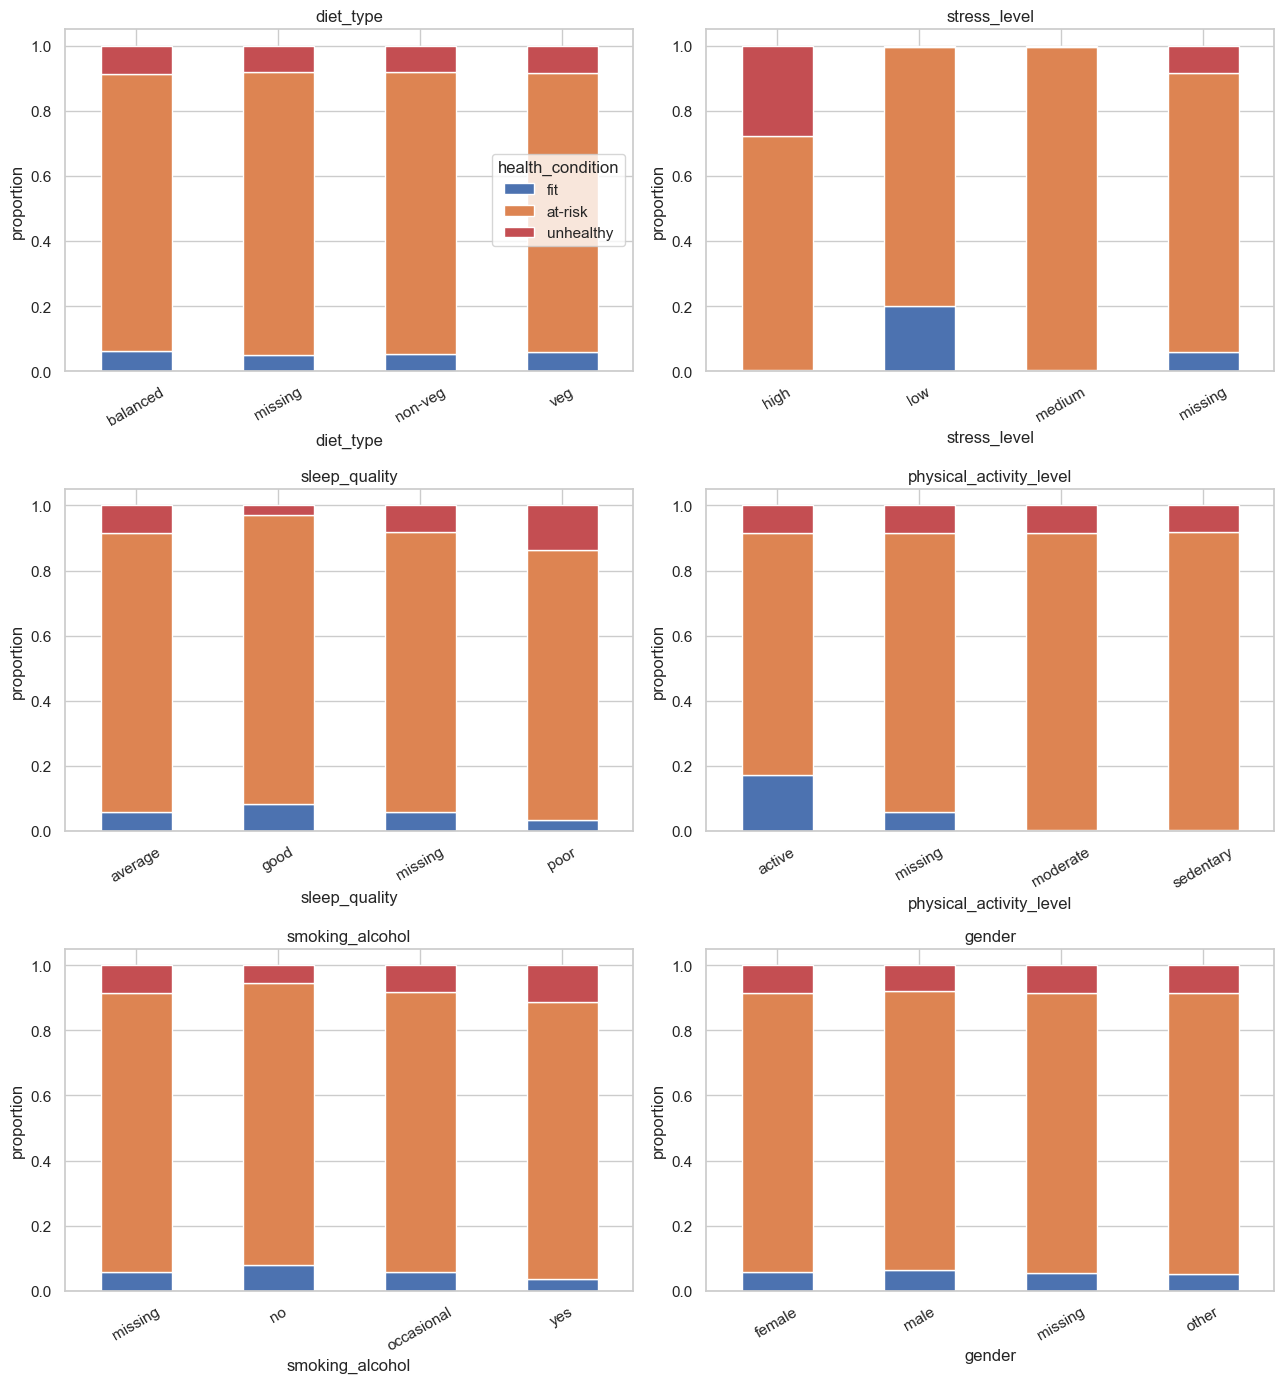

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(13, 14))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL_COLS):
    ct = pd.crosstab(train[col].fillna("missing"), train[TARGET], normalize="index")
    ct = ct.reindex(columns=TARGET_ORDER)
    ct.plot(kind="bar", stacked=True, ax=axes[i],
            color=["#4C72B0", "#DD8452", "#C44E52"], legend=(i == 0))
    axes[i].set_title(col)
    axes[i].set_ylabel("proportion")
    axes[i].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 4. 수치형 피처 상관관계

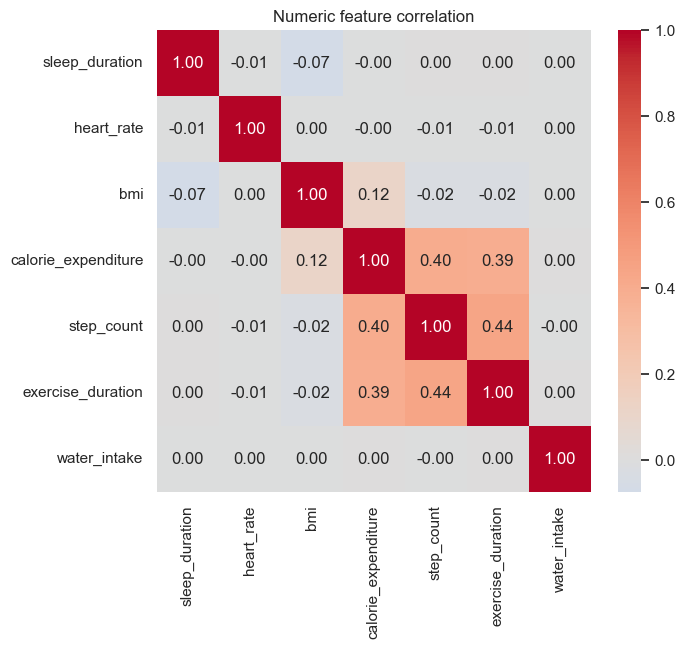

In [6]:
corr = train[NUMERIC_COLS].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Numeric feature correlation")
plt.show()

## 5. 결측 여부와 타겟의 관계

각 피처에 대해 '결측인 행'과 '결측 아닌 행'의 타겟 분포를 비교합니다. 차이가 크면 결측 플래그(`_isnull`)가 실제로 유용한 피처라는 뜻입니다.

In [7]:
FEATURE_COLS = NUMERIC_COLS + CATEGORICAL_COLS
rows = []
overall = train[TARGET].value_counts(normalize=True)

for col in FEATURE_COLS:
    is_null = train[col].isna()
    dist_missing = train.loc[is_null, TARGET].value_counts(normalize=True)
    dist_present = train.loc[~is_null, TARGET].value_counts(normalize=True)
    row = {"feature": col, "missing_rate": is_null.mean()}
    for cls in TARGET_ORDER:
        row[f"{cls}_rate_when_missing"] = dist_missing.get(cls, np.nan)
        row[f"{cls}_rate_when_present"] = dist_present.get(cls, np.nan)
    rows.append(row)

missing_vs_target = pd.DataFrame(rows).set_index("feature")
missing_vs_target.round(4)

,missing_rate,fit_rate_when_missing,fit_rate_when_present,at-risk_rate_when_missing,at-risk_rate_when_present,unhealthy_rate_when_missing,unhealthy_rate_when_present
feature,,,,,,,
sleep_duration,0.1101,0.0573,0.0577,0.8593,0.8586,0.0834,0.0837
heart_rate,0.0114,0.0553,0.0577,0.8708,0.8585,0.0739,0.0838
bmi,0.0201,0.0820,0.0572,0.8888,0.8581,0.0293,0.0848
calorie_expenditure,0.0766,0.0580,0.0577,0.8580,0.8587,0.0840,0.0836
step_count,0.0202,0.0570,0.0577,0.8621,0.8586,0.0809,0.0837
exercise_duration,0.0100,0.0604,0.0577,0.8509,0.8588,0.0887,0.0836
water_intake,0.0630,0.0581,0.0577,0.8551,0.8589,0.0869,0.0834
diet_type,0.0100,0.0509,0.0577,0.8676,0.8586,0.0816,0.0837
stress_level,0.1200,0.0575,0.0577,0.8589,0.8586,0.0836,0.0837


## 6. 핵심 인사이트 정리

**타겟 분포**: at-risk 85.9% / unhealthy 8.4% / fit 5.8% — 심한 불균형. Balanced Accuracy 최적화 시 소수 클래스(fit, unhealthy) recall이 관건.

**범주형 피처 — 압도적으로 강한 신호**
- `stress_level`이 가장 강력한 예측 변수: `medium`이면 at-risk가 **99.4%**, `low`면 fit이 20.1%로 급상승, `high`면 unhealthy가 27.9%까지 상승 (전체 평균 8.4% 대비 3배 이상).
- `physical_activity_level`도 매우 강함: `active`면 fit 비율이 17.2%(평균 대비 3배), `sedentary`/`moderate`는 fit이 거의 0%에 수렴.
- `sleep_quality`: `poor`면 unhealthy 13.6%(평균 대비 +5.2pp), `good`이면 fit 8.2% / unhealthy 3.0%로 뚜렷한 대비.
- `smoking_alcohol`: `yes`면 unhealthy 11.2%, `no`면 fit 7.9% — 약~중간 신호.
- `diet_type`, `gender`는 타겟과 거의 무관 (모든 카테고리에서 타겟 비율이 전체 평균과 거의 동일) → 예측 기여도 낮을 가능성.

**수치형 피처 — 뚜렷하지만 범주형보다는 약한 신호**
- `fit` 그룹이 다른 그룹 대비 확연히 다름: `sleep_duration` 평균 7.95(vs at-risk 7.09, unhealthy 5.37), `step_count` 11,651(vs 8,407 / 8,670), `exercise_duration` 50.0(vs 38.0 / 39.0), `bmi` 21.83로 가장 낮음.
- `heart_rate`, `water_intake`는 클래스 간 평균 차이가 거의 없음(전부 ~75 / ~2.19) → 예측 기여도 낮을 가능성.

**상관관계**: 수치형 피처 간 상관계수가 전부 0에 가까움(다중공선성 없음) → 피처 제거/차원축소 불필요, 각 피처가 독립적인 정보를 담고 있음.

**결측 여부와 타겟의 관계**: 대부분의 `_isnull` 플래그는 결측/비결측 그룹 간 타겟 비율 차이가 1%p 미만으로 거의 신호가 없음. 유일한 예외는 **`bmi`**: 결측일 때 unhealthy 2.9% / fit 8.2%인 반면, 값이 있을 때는 unhealthy 8.5% / fit 5.7%로 차이가 뚜렷함 → `bmi_isnull` 플래그는 유지할 가치가 있고, 나머지 `_isnull` 플래그들은 트리 모델 성능에 큰 영향은 없을 것으로 예상(다만 LightGBM/CatBoost는 저비용이라 일단 다 넣고 feature importance로 걸러도 무방).

**모델링 방향 제안**
1. 범주형(특히 `stress_level`, `physical_activity_level`, `sleep_quality`) 위주로 강한 트리 분기가 생길 것 → LightGBM/CatBoost 등 트리 기반 모델이 유리
2. `medium` stress → at-risk 99.4%처럼 거의 결정적인 규칙이 있어 베이스라인만으로도 balanced accuracy가 꽤 높게 나올 가능성 있음
3. 수치형 피처는 보조 신호로 활용, `diet_type`/`gender`/`heart_rate`/`water_intake`는 제거해도 성능 큰 손실 없을지 실험 필요
4. 여전히 소수 클래스(fit) recall이 병목일 수 있으므로 class_weight 또는 threshold 조정 실험 필요
